# Homework Starter — Stage 10a: Linear Regression

Use this as a scaffold if your project data isn’t ready. Replace the synthetic data section with your dataset when possible.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

## 1) Synthetic data (replace with your project data when ready)
- Finance-flavored factors and asset excess return
- Includes a quadratic effect to motivate specification checks

In [2]:
n = 200
dates = pd.bdate_range(start="2024-02-01", periods=n)
mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)

beta0, beta_mkt, beta_size, beta_value, beta_mom, beta_mom2 = 0.0001, 0.9, 0.25, -0.15, 0.35, 3.5
noise_scale = 0.0035 + 0.5*np.abs(mkt_excess)
eps = np.random.normal(0, noise_scale)
asset_excess = (
    beta0 + beta_mkt*mkt_excess + beta_size*size + beta_value*value + beta_mom*momentum
    + beta_mom2*(momentum**2) + eps
)
df = pd.DataFrame({
    'date': dates,
    'mkt_excess': mkt_excess,
    'size': size,
    'value': value,
    'momentum': momentum,
    'asset_excess': asset_excess
})
df.head()

,date,mkt_excess,size,value,momentum,asset_excess
0,2024-02-01,0.018596,-0.013467,-0.000540,0.000141,0.014832
1,2024-02-02,-0.005125,0.008120,0.007089,-0.006840,-0.008599
2,2024-02-05,0.000361,-0.011532,-0.012885,-0.011216,-0.009577
3,2024-02-06,0.004483,-0.010749,0.003905,-0.010685,0.000033
4,2024-02-07,-0.008678,-0.002893,0.001250,0.002779,-0.005750


## 2) Baseline model fit
Follow the steps; replace `df` with your project DataFrame when ready.

In [3]:
X = df[['mkt_excess','size','value','momentum']]
y = df['asset_excess']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Baseline   R²={r2:.4f}  RMSE={rmse:.6f}')

Baseline   R²=0.3677  RMSE=0.008470


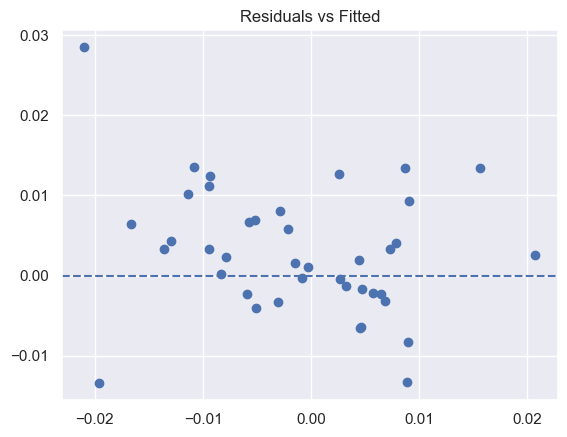

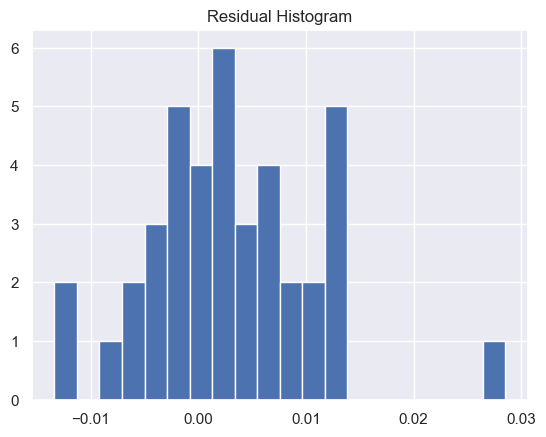

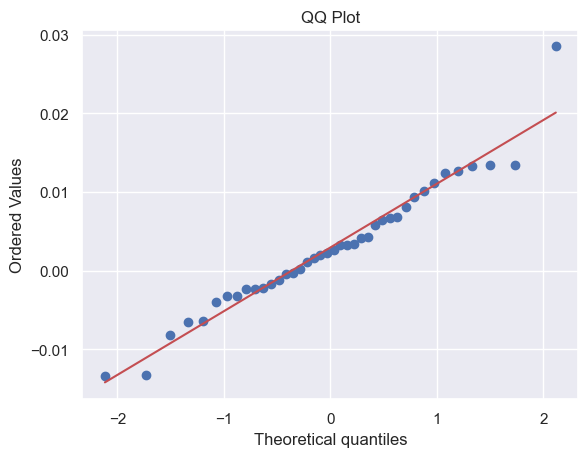

In [4]:
resid = y_test - y_pred
fitted = y_pred
plt.figure(); plt.scatter(fitted, resid); plt.axhline(0, ls='--'); plt.title('Residuals vs Fitted'); plt.show()
plt.figure(); plt.hist(resid, bins=20); plt.title('Residual Histogram'); plt.show()
plt.figure(); st.probplot(resid, dist='norm', plot=plt); plt.title('QQ Plot'); plt.show()

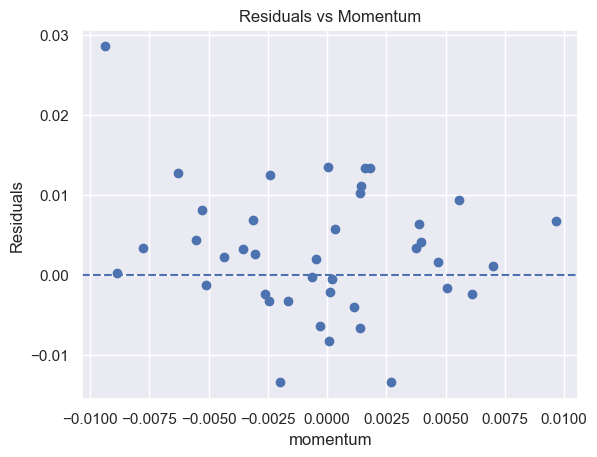

In [ ]:
# take momentum value（ X_test already has momentum col）
momentum_test = X_test['momentum']

plt.figure()
plt.scatter(momentum_test, resid)
plt.axhline(0, ls='--')
plt.xlabel('momentum')
plt.ylabel('Residuals')
plt.title('Residuals vs Momentum')
plt.show()

## 3) Optional: Add a transformed feature
Add a polynomial or interaction if diagnostics suggest mis-specification.

In [7]:
df['momentum_sq'] = df['momentum']**2
X2 = df[['mkt_excess','size','value','momentum','momentum_sq']]
X2_train, X2_test = X2.iloc[:len(X_train)], X2.iloc[len(X_train):]
lr2 = LinearRegression().fit(X2_train, y_train)
y_pred2 = lr2.predict(X2_test)
r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f'With x^2   R²={r2_2:.4f}  RMSE={rmse_2:.6f}')

With x^2   R²=0.3681  RMSE=0.008467


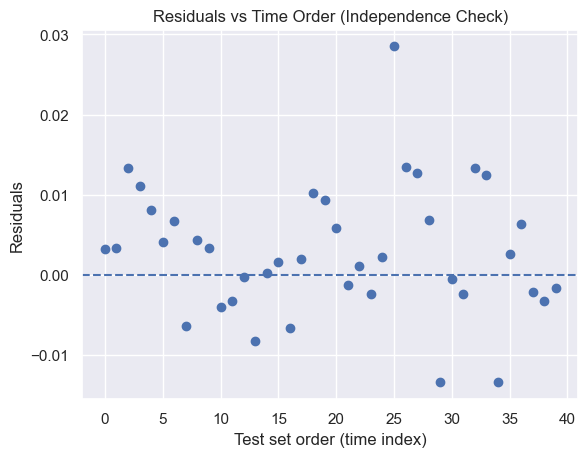

In [8]:
plt.figure()
plt.scatter(range(len(resid)), resid)
plt.axhline(0, ls='--')
plt.xlabel('Test set order (time index)')
plt.ylabel('Residuals')
plt.title('Residuals vs Time Order (Independence Check)')
plt.show()

## 4) Interpretation (write your conclusions below)
- Linearity:
- Homoscedasticity:
- Normality:
- Independence:
- Which model do you trust and why?:
- Next step you’d try:

## 4) Interpretation

- **Linearity:** The residuals vs. fitted plot shows no strong curvature; points scatter
  fairly randomly around zero. The residuals vs. momentum plot shows a weak, non-conclusive
  U-shaped tendency at the extremes, consistent with the fact that the data-generating
  process includes a momentum² term. However, this signal is faint given the small test
  set (n=40).

- **Homoscedasticity:** No obvious funnel shape is visible in the residuals vs. fitted plot,
  though a couple of points with larger fitted-value magnitudes also show larger residuals,
  loosely consistent with the volatility-linked noise built into the data.

- **Normality:** The bulk of residuals in the Q-Q plot follow the 45° line closely, but both
  tails deviate — a few points fall well off the line, and the histogram shows a lone outlier
  bar on the right. This indicates mild heavy-tailedness rather than perfect normality.

- **Independence:** The residuals vs. time-order plot shows no clear trend or runs of
  same-signed residuals; points appear to fluctuate randomly around zero, suggesting no
  strong autocorrelation.

- **Which model do you trust and why?:** I trust the baseline model (without momentum²) over
  the extended one. Although the residuals vs. momentum plot hinted at a possible non-linear
  effect, adding momentum² produced almost no improvement (R²: 0.3677 → 0.3681, RMSE:
  0.008470 → 0.008467). Given the added complexity isn't justified by the data, the simpler
  baseline model is preferable (Occam's razor). Both models explain roughly 37% of the
  variance in asset excess returns — reasonable for noisy daily financial return data, but
  far from complete, so I'd treat this model as informative for explanation (directionally
  understanding factor exposures) rather than as a precise prediction tool.

- **Next step you'd try:** Given the mild heavy tails and possible outliers, I'd investigate
  whether a few specific dates are driving the extreme residuals (e.g., high-volatility days),
  and consider a small out-of-sample validation across a longer time period to check whether
  the weak non-linearity in momentum is a real, recoverable signal or just noise from the
  small sample size.